# Day 2 — Validate ReplicatorAgent against the reference model

Runs ReplicatorBench's `execute-easy` and `interpret-easy` stages against `our_models/scarcity_of_labor` (design is already hand-authored in `replication_info.json`), then numerically diffs the agent-generated model against the independent reference implementation in `for_reference/reference_model/`.

`for_reference/reference_model/`'s own interpret stage only compares free-text summaries, so it can miss a wrong sign or magnitude (see `README.md`'s Known limitations). This notebook adds the numeric check that stage doesn't do.

In [1]:
import json
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
EXECUTION_DIR = NOTEBOOK_DIR.parent
REPO_ROOT = EXECUTION_DIR.parent

STUDY_NAME = "scarcity_of_labor"
STUDY_DIR = REPO_ROOT / "agent_workspace" / "baseline"
ARTIFACTS_DIR = STUDY_DIR / "outputs"
REFERENCE_MODEL_DIR = REPO_ROOT / "for_reference" / "reference_model"
COMPARISON_DIR = (
    REPO_ROOT
    / "for_reference"
    / "outputs"
    / "comparisons"
    / STUDY_NAME
    / datetime.now().strftime("%Y%m%d_%H%M%S")
)

MODEL = "codex"

sys.path.insert(0, str(REFERENCE_MODEL_DIR))
import model as reference_model

print("Study:", STUDY_DIR)
print("Model:", MODEL)
print("Comparison output:", COMPARISON_DIR)

Study: /home/stephen/sysrisk/execution/our_models/scarcity_of_labor/input
Model: gpt-5.4-mini
Comparison output: /home/stephen/sysrisk/for_reference/outputs/comparisons/scarcity_of_labor/20260722_164421


## Use existing Codex baseline outputs

This notebook does not launch Codex. It validates the already-generated files in `agent_workspace/baseline/outputs/` against the independent reference model.


In [ ]:
required_outputs = [
    ARTIFACTS_DIR / "left_results.json",
    ARTIFACTS_DIR / "right_results.json",
]

missing_outputs = [path for path in required_outputs if not path.exists()]
assert not missing_outputs, f"Missing Codex outputs: {missing_outputs}"

print("Found Codex outputs:")
for path in required_outputs:
    print("-", path)


## Load the Codex output

The Codex-generated implementation writes one JSON file per Figure 6 case under `agent_workspace/baseline/outputs/`.


In [4]:
def load_agent_case(name: str) -> dict:
    with (ARTIFACTS_DIR / f"{name}_results.json").open() as f:
        return json.load(f)


agent_cases = {name: load_agent_case(name) for name in ("left", "right")}
{name: case["parameters"] for name, case in agent_cases.items()}

{'left': {'K': 1, 'L': 1, 'sigma': 0.5, 'A': 1.0},
 'right': {'K': 10, 'L': 1, 'sigma': 0.2, 'A': 1.0}}

## Cross-validate against the reference model

Re-evaluates `reference_model.compute_equilibrium()` at exactly the `(phi, K, L, sigma, A)` points the agent reported, rather than assuming a shared grid or hardcoded parameter set - this also works if the agent is later rerun under a different parameter set.

In [5]:
AGENT_TO_REFERENCE_FIELDS = {
    "Y": "output",
    "w": "wage",
    "R": "capital_return",
    "wage_bill": "wage_bill",
    "capital_income": "capital_income",
}


def compare_case(name: str, agent_case: dict) -> pd.DataFrame:
    params = agent_case["parameters"]
    agent_df = pd.DataFrame(agent_case["results"])

    reference_rows = [
        reference_model.compute_equilibrium(
            phi=phi,
            capital=params["K"],
            labor=params["L"],
            sigma=params["sigma"],
            productivity=params["A"],
        )
        for phi in agent_df["phi"]
    ]
    reference_df = pd.DataFrame(reference_rows)

    comparison = pd.DataFrame({"case": name, "phi": agent_df["phi"]})
    for agent_field, reference_field in AGENT_TO_REFERENCE_FIELDS.items():
        comparison[f"agent_{agent_field}"] = agent_df[agent_field]
        comparison[f"reference_{agent_field}"] = reference_df[reference_field]
        comparison[f"abs_diff_{agent_field}"] = (
            comparison[f"agent_{agent_field}"] - comparison[f"reference_{agent_field}"]
        ).abs()

    return comparison


comparisons = pd.concat(
    (compare_case(name, case) for name, case in agent_cases.items()),
    ignore_index=True,
)
comparisons.head()

,case,phi,agent_Y,reference_Y,abs_diff_Y,agent_w,reference_w,abs_diff_w,agent_R,reference_R,abs_diff_R,agent_wage_bill,reference_wage_bill,abs_diff_wage_bill,agent_capital_income,reference_capital_income,abs_diff_capital_income
0,left,0.000,1.000000,1.000000,0.0,-1.000000,1.000000,2.000000,-0.000000,0.000000,0.000000,-1.000000,1.000000,2.000000,-0.000000,0.000000,0.000000
1,left,0.002,1.004008,1.004008,0.0,-1.004004,1.004004,2.008008,-0.000004,0.000004,0.000008,-1.004004,1.004004,2.008008,-0.000004,0.000004,0.000008
2,left,0.004,1.008032,1.008032,0.0,-1.008016,1.008016,2.016031,-0.000016,0.000016,0.000033,-1.008016,1.008016,2.016031,-0.000016,0.000016,0.000033
3,left,0.006,1.012072,1.012072,0.0,-1.012035,1.012035,2.024070,-0.000037,0.000037,0.000074,-1.012035,1.012035,2.024070,-0.000037,0.000037,0.000074
4,left,0.008,1.016128,1.016128,0.0,-1.016062,1.016062,2.032124,-0.000066,0.000066,0.000132,-1.016062,1.016062,2.032124,-0.000066,0.000066,0.000132


In [6]:
diff_columns = [column for column in comparisons.columns if column.startswith("abs_diff_")]

max_abs_diff = comparisons.groupby("case")[diff_columns].max()
max_abs_diff.columns = [column.removeprefix("abs_diff_") for column in max_abs_diff.columns]

sign_mismatches = {
    field: int((comparisons[f"agent_{field}"] * comparisons[f"reference_{field}"] < 0).sum())
    for field in AGENT_TO_REFERENCE_FIELDS
}

print("Max absolute difference (agent vs. reference), per case:")
display(max_abs_diff)
print("\nRows where agent and reference disagree on sign, per field:")
print(json.dumps(sign_mismatches, indent=2))

Max absolute difference (agent vs. reference), per case:


,Y,w,R,wage_bill,capital_income
case,,,,,
left,0.0,2.914198,1.983969,2.914198,1.983969
right,0.0,34.089689,4.969168,34.089689,49.691677



Rows where agent and reference disagree on sign, per field:
{
  "Y": 0,
  "w": 705,
  "R": 703,
  "wage_bill": 705,
  "capital_income": 703
}


## Visualize agent vs. reference

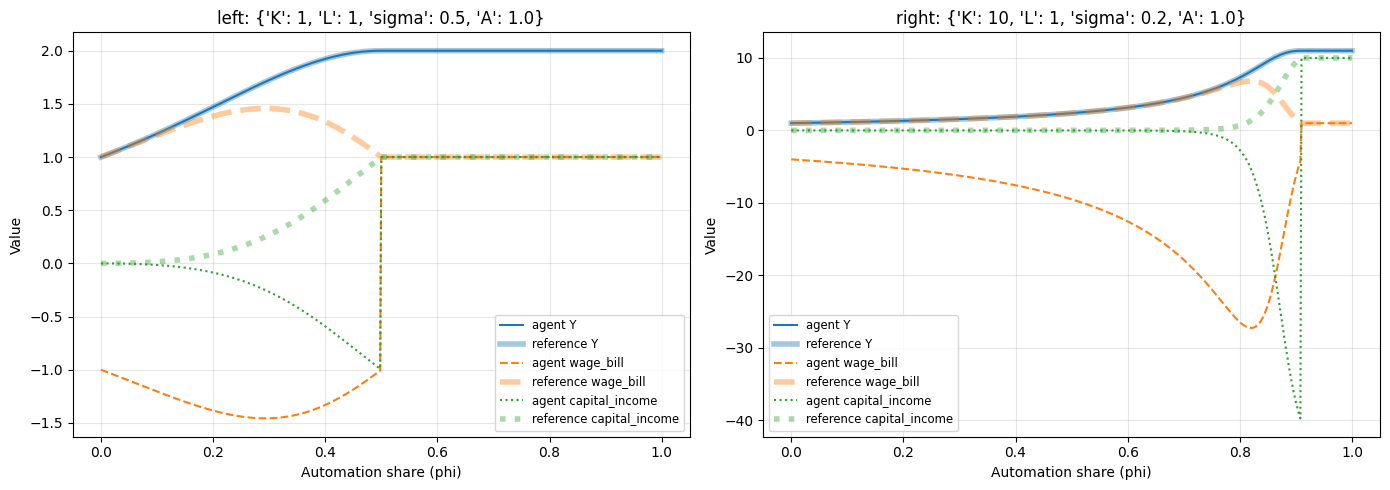

In [7]:
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

figure, axes = plt.subplots(1, len(agent_cases), figsize=(7 * len(agent_cases), 5), squeeze=False)

for axis, (name, case) in zip(axes.flatten(), agent_cases.items()):
    case_data = comparisons[comparisons["case"] == name]

    for agent_field, style in (("Y", "-"), ("wage_bill", "--"), ("capital_income", ":")):
        color = axis.plot(
            case_data["phi"], case_data[f"agent_{agent_field}"], style, label=f"agent {agent_field}"
        )[0].get_color()
        axis.plot(
            case_data["phi"],
            case_data[f"reference_{agent_field}"],
            style,
            color=color,
            alpha=0.4,
            linewidth=4,
            label=f"reference {agent_field}",
        )

    axis.set_title(f"{name}: {case['parameters']}")
    axis.set_xlabel("Automation share (phi)")
    axis.set_ylabel("Value")
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize="small")

figure.tight_layout()
figure.savefig(COMPARISON_DIR / "agent_vs_reference.png", dpi=150, bbox_inches="tight")
plt.show()

## Save the comparison

Mirrors `run_study.sh`'s `for_reference/outputs/agent/<study>/<timestamp>/` snapshot convention, under the `comparisons/` folder reserved for this in the README.

In [8]:
comparisons.to_csv(COMPARISON_DIR / "comparison.csv", index=False)

verdict = {
    "study": STUDY_NAME,
    "model": MODEL,
    "max_abs_diff": max_abs_diff.to_dict(orient="index"),
    "sign_mismatches": sign_mismatches,
}
with (COMPARISON_DIR / "summary.json").open("w") as f:
    json.dump(verdict, f, indent=2)

print("Saved comparison to", COMPARISON_DIR)
print(json.dumps(verdict, indent=2))

Saved comparison to /home/stephen/sysrisk/for_reference/outputs/comparisons/scarcity_of_labor/20260722_164421
{
  "study": "scarcity_of_labor",
  "model": "gpt-5.4-mini",
  "max_abs_diff": {
    "left": {
      "Y": 0.0,
      "w": 2.91419770585784,
      "R": 1.983968512499704,
      "wage_bill": 2.91419770585784,
      "capital_income": 1.983968512499704
    },
    "right": {
      "Y": 0.0,
      "w": 34.0896890504488,
      "R": 4.969167728202532,
      "wage_bill": 34.0896890504488,
      "capital_income": 49.69167728202532
    }
  },
  "sign_mismatches": {
    "Y": 0,
    "w": 705,
    "R": 703,
    "wage_bill": 705,
    "capital_income": 703
  }
}
